In [ ]:
# Basic data handling
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# For Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

# Handle class imbalance
from imblearn.over_sampling import SMOTE, ADASYN



# Accuracy metrixs
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
   
)
# Machine learning models
from sklearn.linear_model import LogisticRegression


# To set the grid of charts
sns.set_style("whitegrid")

# Set a random seed so results are reproducible every time we run this notebook
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

import warnings
warnings.filterwarnings("ignore")

Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


In [2]:
# For consistent Chart Style & color scheme
NORMAL_COLOR = "#4C72B0"
FRAUD_COLOR = "#C44E52"

# same as NORMAL_COLOR, used for single-series charts
ACCENT_COLOR = "#4C72B0"

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 10

# Add value labels above/beside each bar
def add_bar_labels(ax, fmt="%.1f"):
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, padding=2, fontsize=9)

# Step 1: Data Loading

## 1.1 Load the Dataset

In [3]:
# Load the dataset
df = pd.read_csv("fraud_data.csv")

print("Raw shape:", df.shape)
df.head()

Raw shape: (14446, 15)


,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
0,04-01-2019 00:58,"""Stokes, Christiansen and Sipes""",grocery_net,14.37,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",09-11-1939,a3806e984cec6ac0096d8184c64ad3a1,65.654142,-164.722603,1
1,04-01-2019 15:06,Predovic Inc,shopping_net,966.11,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",09-11-1939,a59185fe1b9ccf21323f581d7477573f,65.468863,-165.473127,1
2,04-01-2019 22:37,Wisozk and Sons,misc_pos,49.61,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",09-11-1939,86ba3a888b42cd3925881fa34177b4e0,65.347667,-165.914542,1
3,04-01-2019 23:06,Murray-Smitham,grocery_pos,295.26,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",09-11-1939,3a068fe1d856f0ecedbed33e4b5f4496,64.445035,-166.080207,1
4,04-01-2019 23:59,Friesen Lt,health_fitness,18.17,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",09-11-1939,891cdd1191028759dc20dc224347a0ff,65.447094,-165.446843,1


## 1.2 Clean the is_fraud Column

In [4]:
# Check what values currently exist in is_fraud
print("Unique values before cleaning:")
print(df["is_fraud"].unique())

# Keep only rows where is_fraud is exactly "0" or "1"
df = df[df["is_fraud"].isin(["0", "1"])].copy()

# Convert to integer type
df["is_fraud"] = df["is_fraud"].astype(int)

print("\nShape after cleaning:", df.shape)
print("Unique values after cleaning:", df["is_fraud"].unique())

Unique values before cleaning:
['1' '1"2020-12-24 16:56:24"' '0' '0"2019-01-01 00:00:44"']

Shape after cleaning: (14444, 15)
Unique values after cleaning: [1 0]


## 1.3 Basic Structure of the Data

In [5]:
# Data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14444 entries, 0 to 14445
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   trans_date_trans_time  14444 non-null  object 
 1   merchant               14444 non-null  object 
 2   category               14444 non-null  object 
 3   amt                    14444 non-null  float64
 4   city                   14444 non-null  object 
 5   state                  14444 non-null  object 
 6   lat                    14444 non-null  float64
 7   long                   14444 non-null  float64
 8   city_pop               14444 non-null  int64  
 9   job                    14444 non-null  object 
 10  dob                    14444 non-null  object 
 11  trans_num              14444 non-null  object 
 12  merch_lat              14444 non-null  float64
 13  merch_long             14444 non-null  float64
 14  is_fraud               14444 non-null  int32  
dtypes: floa

In [6]:
# Check for missing values in each column
df.isnull().sum()

trans_date_trans_time    0
merchant                 0
category                 0
amt                      0
city                     0
state                    0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

## 1.4 Class Imbalance Check

In [7]:
# Check for the class imbalance
class_counts = df["is_fraud"].value_counts()
print(class_counts)

# Calculate the percentage of the fraud in 0 & 1s
class_percent = df["is_fraud"].value_counts(normalize=True) * 100
print("\nPercentage:")
print(class_percent)

is_fraud
0    12600
1     1844
Name: count, dtype: int64

Percentage:
is_fraud
0    87.233453
1    12.766547
Name: proportion, dtype: float64


# Step 2: Exploratory Data Analysis

## 2.1 Visualize the Class Imbalance

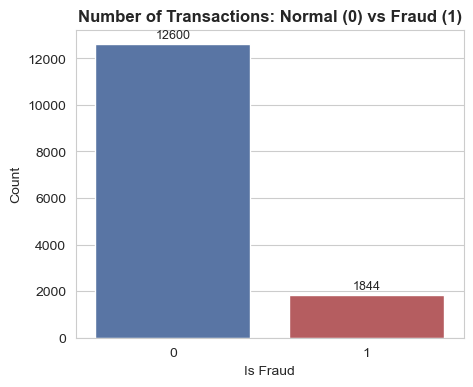

In [8]:
# Visualize the class imbalance
plt.figure(figsize=(5, 4))
ax = sns.countplot(x="is_fraud", data=df, hue="is_fraud",
                    palette=[NORMAL_COLOR, FRAUD_COLOR], legend=False)
add_bar_labels(ax, fmt="%.0f")
plt.title("Number of Transactions: Normal (0) vs Fraud (1)")
plt.xlabel("Is Fraud")
plt.ylabel("Count")
plt.show()

## 2.2 Comparision of Transaction Amount Statistics for Fraud vs Normal

In [9]:
# Compare transaction amount statistics for fraud vs normal
print("Normal transactions - amt statistics:")
print(df[df["is_fraud"] == 0]["amt"].describe())

print("\nFraud transactions - amt statistics:")
print(df[df["is_fraud"] == 1]["amt"].describe())

Normal transactions - amt statistics:
count    12600.000000
mean        66.814898
std        114.481015
min          1.000000
25%          9.770000
50%         46.140000
75%         81.927500
max       3261.470000
Name: amt, dtype: float64

Fraud transactions - amt statistics:
count    1844.000000
mean      518.233015
std       389.925972
min         1.780000
25%       187.350000
50%       358.655000
75%       884.222500
max      1371.810000
Name: amt, dtype: float64


## 2.3 Amount Distribution for Fraud & Normal

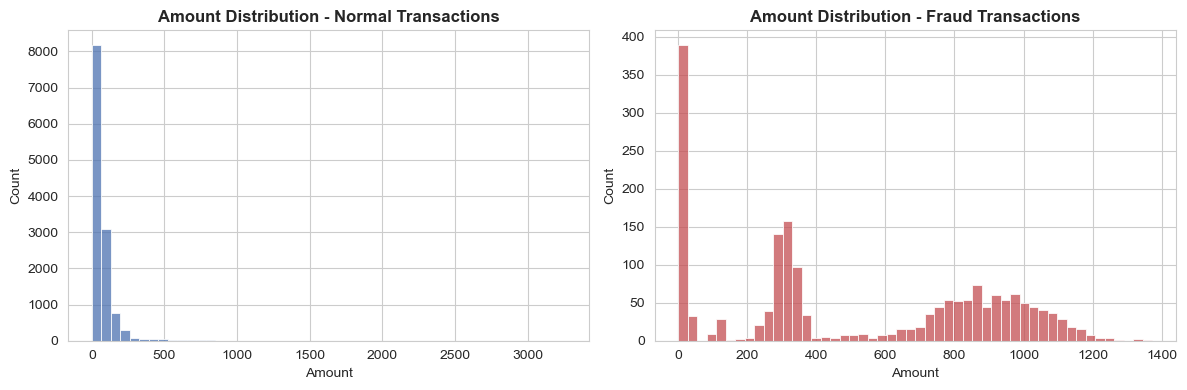

In [10]:
# Plot amount distribution for both classes
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df[df["is_fraud"] == 0]["amt"], bins=50, ax=ax[0], color=NORMAL_COLOR)
ax[0].set_title("Amount Distribution - Normal Transactions")
ax[0].set_xlabel("Amount")

sns.histplot(df[df["is_fraud"] == 1]["amt"], bins=50, ax=ax[1], color=FRAUD_COLOR)
ax[1].set_title("Amount Distribution - Fraud Transactions")
ax[1].set_xlabel("Amount")

plt.tight_layout()
plt.show()

## 2.4 Fraud Rate by Merchant Category

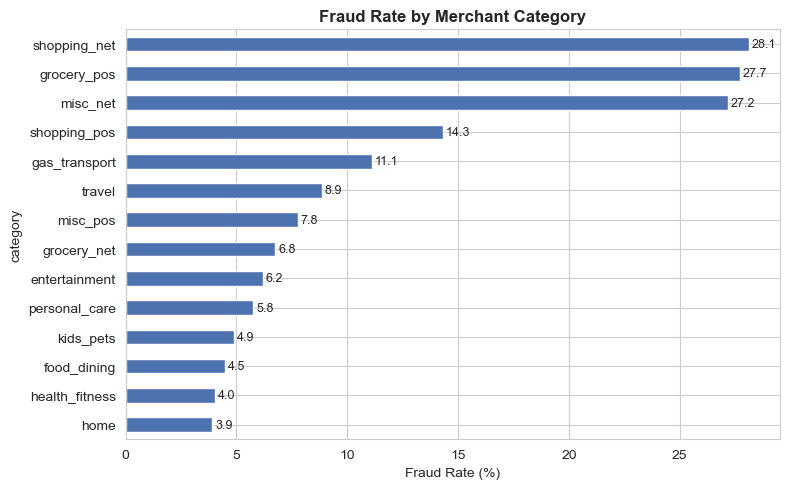

In [11]:
# Fraud rate by merchant category
category_fraud_rate = df.groupby("category")["is_fraud"].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(8, 5))
ax = category_fraud_rate.plot(kind="barh", color=ACCENT_COLOR)
add_bar_labels(ax, fmt="%.1f")
plt.xlabel("Fraud Rate (%)")
plt.title("Fraud Rate by Merchant Category")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 2.5 Fraud Rate by State.

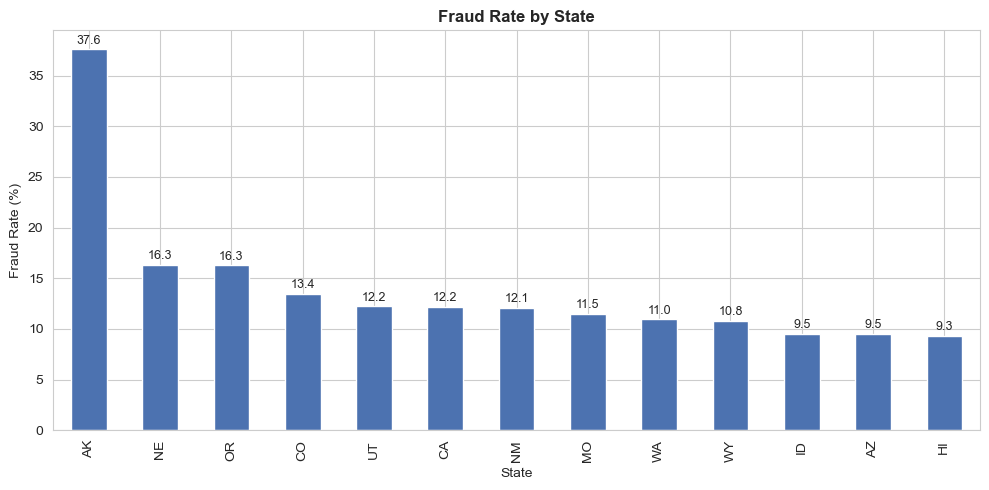

In [12]:
# Fraud rate by state
state_fraud_rate = df.groupby("state")["is_fraud"].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10, 5))
ax = state_fraud_rate.plot(kind="bar", color=ACCENT_COLOR)
add_bar_labels(ax, fmt="%.1f")
plt.xlabel("State")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by State")
plt.tight_layout()
plt.show()


## 2.6 Transaction Time Patterns

In [13]:
# Parse the transaction datetime (format is day-month-year hour:minute)
df["trans_datetime"] = pd.to_datetime(df["trans_date_trans_time"], format="%d-%m-%Y %H:%M")

# Extract hour of day and day of week
df["trans_hour"] = df["trans_datetime"].dt.hour
df["trans_dayofweek"] = df["trans_datetime"].dt.day_name()

df[["trans_date_trans_time", "trans_datetime", "trans_hour", "trans_dayofweek"]].head()

,trans_date_trans_time,trans_datetime,trans_hour,trans_dayofweek
0,04-01-2019 00:58,2019-01-04 00:58:00,0,Friday
1,04-01-2019 15:06,2019-01-04 15:06:00,15,Friday
2,04-01-2019 22:37,2019-01-04 22:37:00,22,Friday
3,04-01-2019 23:06,2019-01-04 23:06:00,23,Friday
4,04-01-2019 23:59,2019-01-04 23:59:00,23,Friday


### 2.6.1 Fraud Rate by Hour of Day

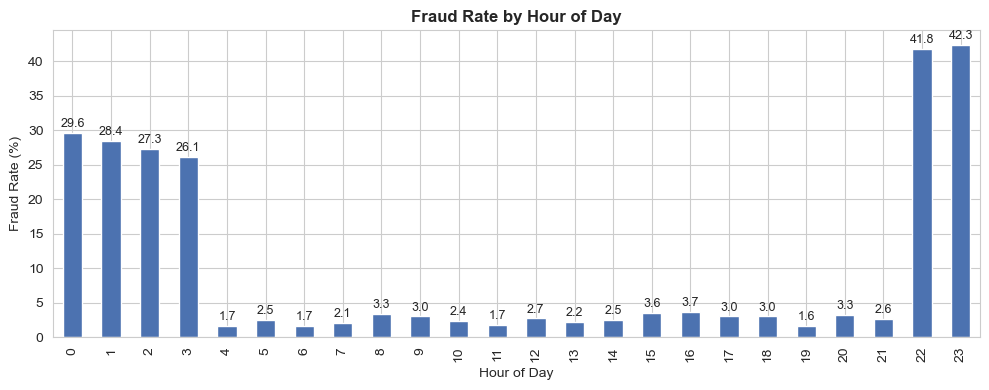

In [14]:
# Fraud rate by hour of day
hour_fraud_rate = df.groupby("trans_hour")["is_fraud"].mean() * 100

plt.figure(figsize=(10, 4))
ax = hour_fraud_rate.plot(kind="bar", color=ACCENT_COLOR)
add_bar_labels(ax, fmt="%.1f")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Hour of Day")
plt.tight_layout()
plt.show()

### 2.6.2 Fraud Rate by Day of Week

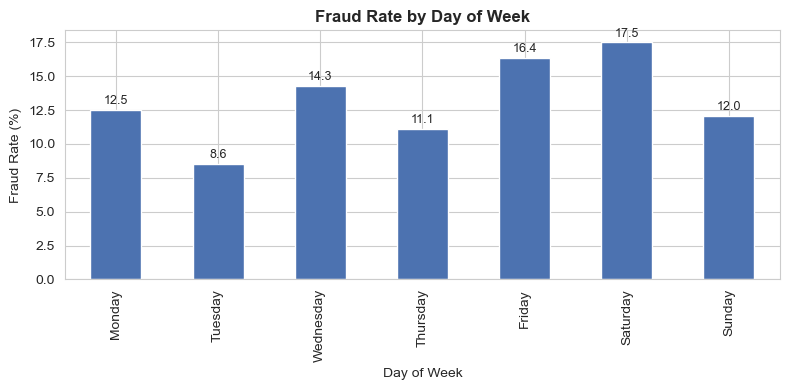

In [15]:
# Fraud rate by day of week
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_fraud_rate = df.groupby("trans_dayofweek")["is_fraud"].mean().reindex(day_order) * 100

plt.figure(figsize=(8, 4))
ax = day_fraud_rate.plot(kind="bar", color=ACCENT_COLOR)
add_bar_labels(ax, fmt="%.1f")
plt.xlabel("Day of Week")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Day of Week")
plt.tight_layout()
plt.show()

## 2.7 Age Distribution by Fraud Vs Normal Transactions

In [16]:
# Parse date of birth and compute customer age at time of transaction
df["dob_parsed"] = pd.to_datetime(df["dob"], format="%d-%m-%Y")
df["age"] = ((df["trans_datetime"] - df["dob_parsed"]).dt.days / 365.25).astype(int)

df[["dob", "age"]].head()

,dob,age
0,09-11-1939,79
1,09-11-1939,79
2,09-11-1939,79
3,09-11-1939,79
4,09-11-1939,79


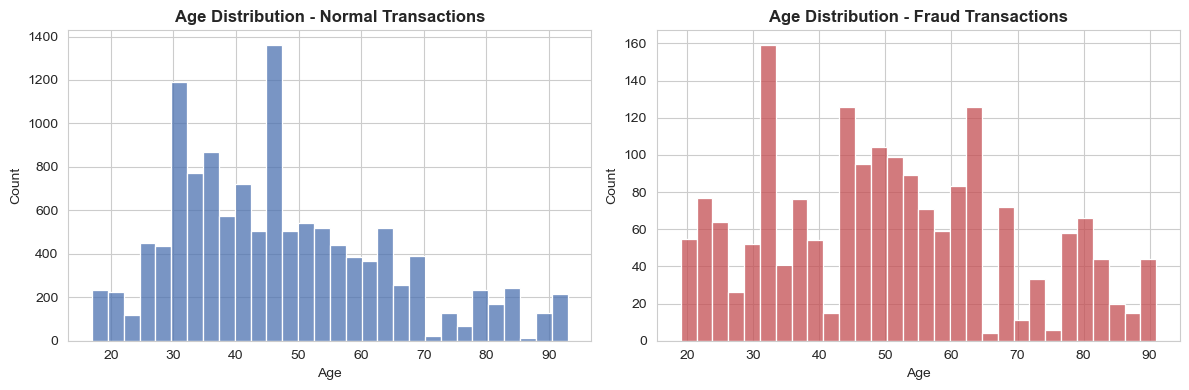

In [17]:
# Age distribution: fraud vs normal
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df[df["is_fraud"] == 0]["age"], bins=30, ax=ax[0], color=NORMAL_COLOR)
ax[0].set_title("Age Distribution - Normal Transactions")
ax[0].set_xlabel("Age")

sns.histplot(df[df["is_fraud"] == 1]["age"], bins=30, ax=ax[1], color=FRAUD_COLOR)
ax[1].set_title("Age Distribution - Fraud Transactions")
ax[1].set_xlabel("Age")

plt.tight_layout()
plt.show()

## 2.8 Customer-Merchant Distance for Fraud Vs Normal Transactions

In [18]:
# Calculate distance (in km) between customer and merchant using the Haversine formula
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth's radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

df["distance_km"] = haversine_distance(df["lat"], df["long"], df["merch_lat"], df["merch_long"])

df["distance_km"].describe()

count    14444.000000
mean        75.825980
std         28.717699
min          0.639325
25%         55.438978
50%         77.946241
75%         97.719597
max        143.559991
Name: distance_km, dtype: float64

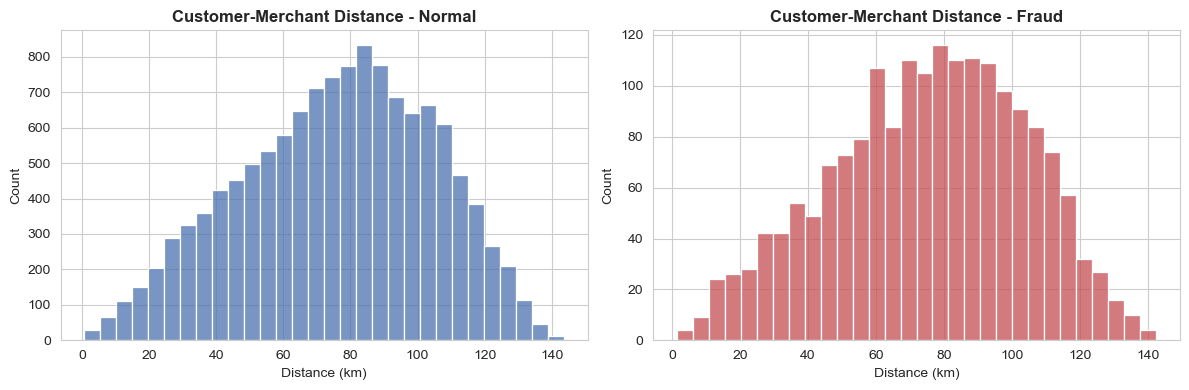

In [19]:
# Distance distribution: fraud vs normal
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df[df["is_fraud"] == 0]["distance_km"], bins=30, ax=ax[0], color=NORMAL_COLOR)
ax[0].set_title("Customer-Merchant Distance - Normal")
ax[0].set_xlabel("Distance (km)")

sns.histplot(df[df["is_fraud"] == 1]["distance_km"], bins=30, ax=ax[1], color=FRAUD_COLOR)
ax[1].set_title("Customer-Merchant Distance - Fraud")
ax[1].set_xlabel("Distance (km)")

plt.tight_layout()
plt.show()

## 2.9 City Population Distribution for Fraud Vs Normal Transactions

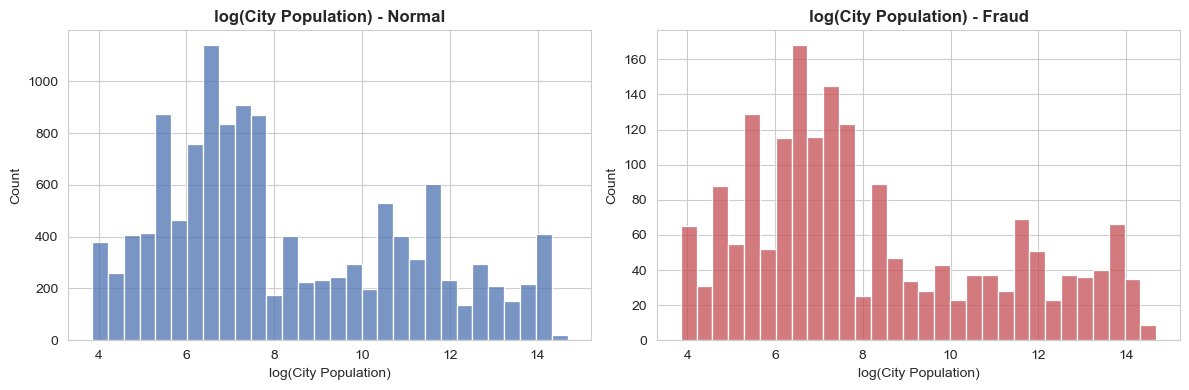

In [20]:
# city_pop is heavily skewed, so log scale is used
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(np.log1p(df[df["is_fraud"] == 0]["city_pop"]), bins=30, ax=ax[0], color=NORMAL_COLOR)
ax[0].set_title("log(City Population) - Normal")
ax[0].set_xlabel("log(City Population)")

sns.histplot(np.log1p(df[df["is_fraud"] == 1]["city_pop"]), bins=30, ax=ax[1], color=FRAUD_COLOR)
ax[1].set_title("log(City Population) - Fraud")
ax[1].set_xlabel("log(City Population)")

plt.tight_layout()
plt.show()

## 2.10 Top 15 Jobs by Fraud Rate

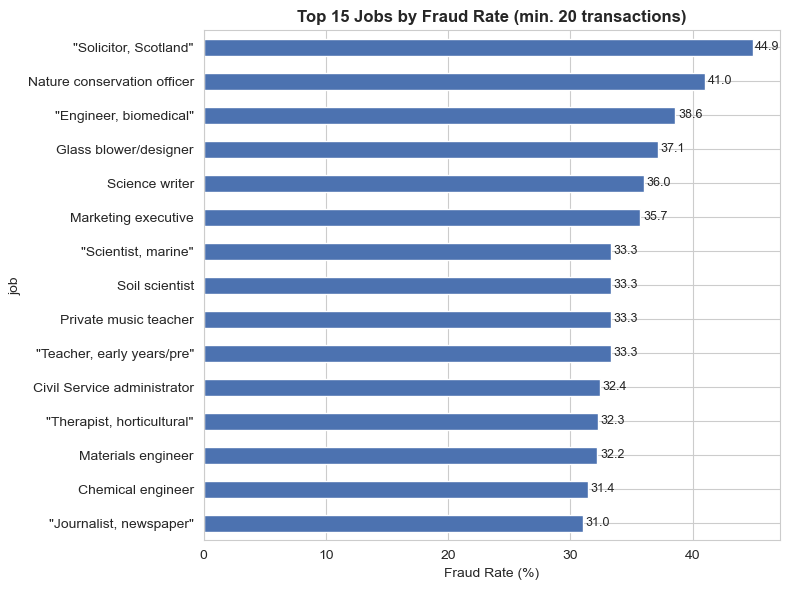

In [21]:
# Only look at jobs with a reasonable number of transactions, to avoid noisy small-sample rates
job_counts = df["job"].value_counts()
common_jobs = job_counts[job_counts >= 20].index

job_fraud_rate = (
    df[df["job"].isin(common_jobs)]
    .groupby("job")["is_fraud"]
    .mean()
    .sort_values(ascending=False)
    .head(15) * 100
)

plt.figure(figsize=(8, 6))
ax = job_fraud_rate.plot(kind="barh", color=ACCENT_COLOR)
add_bar_labels(ax, fmt="%.1f")
plt.xlabel("Fraud Rate (%)")
plt.title("Top 15 Jobs by Fraud Rate (min. 20 transactions)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 2.11 Transaction Amount by Class

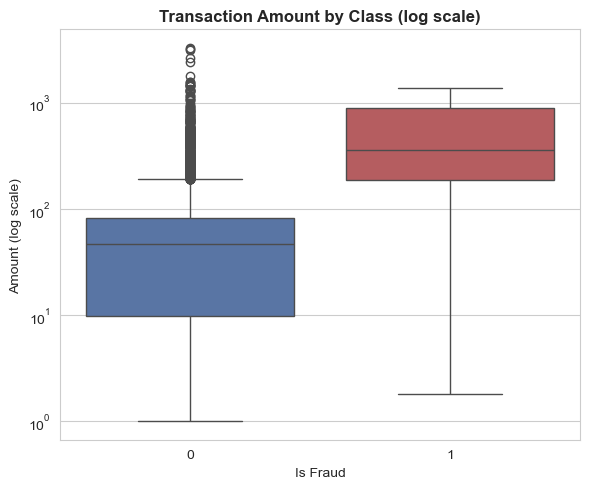

In [22]:
# Boxplot gives a cleaner view of the amount difference than histograms alone
plt.figure(figsize=(6, 5))
sns.boxplot(x="is_fraud", y="amt", data=df, hue="is_fraud",
            palette=[NORMAL_COLOR, FRAUD_COLOR], legend=False)
plt.yscale("log")
plt.xlabel("Is Fraud")
plt.ylabel("Amount (log scale)")
plt.title("Transaction Amount by Class (log scale)")
plt.tight_layout()
plt.show()

## 2.12 Correlation Heatmap for Numeric Features

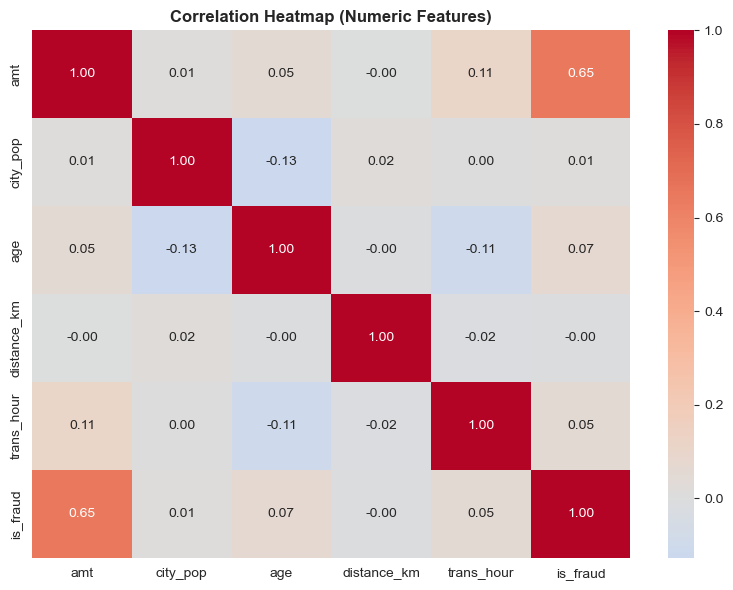

In [23]:
# Correlation heatmap of the numeric columns including the engineered ones
numeric_cols = ["amt", "city_pop", "age", "distance_km", "trans_hour", "is_fraud"]

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()

# Step 3: Preprocessing

## 3.1 Choose the Final Feature set

In [24]:
# Drop below columns
drop_cols = [
    "trans_num", "trans_date_trans_time", "trans_datetime",
    "dob", "dob_parsed", "merchant", "city", "job",
    "lat", "long", "merch_lat", "merch_long",
]

features_df = df.drop(columns=drop_cols)
features_df.columns.tolist()

['category',
 'amt',
 'state',
 'city_pop',
 'is_fraud',
 'trans_hour',
 'trans_dayofweek',
 'age',
 'distance_km']

## 3.2 Encode Categorical Features

In [25]:
# One-hot encode the categorical columns
categorical_cols = ["category", "state", "trans_dayofweek"]

features_df = pd.get_dummies(features_df, columns=categorical_cols, drop_first=True)

print("Shape after encoding:", features_df.shape)
features_df.head()

Shape after encoding: (14444, 37)


,amt,city_pop,is_fraud,trans_hour,age,distance_km,category_food_dining,category_gas_transport,category_grocery_net,category_grocery_pos,...,state_OR,state_UT,state_WA,state_WY,trans_dayofweek_Monday,trans_dayofweek_Saturday,trans_dayofweek_Sunday,trans_dayofweek_Thursday,trans_dayofweek_Tuesday,trans_dayofweek_Wednesday
0,14.37,145,1,0,79,109.285552,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,966.11,145,1,15,79,79.856896,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,49.61,145,1,22,79,66.807915,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,295.26,145,1,23,79,39.636227,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,18.17,145,1,23,79,77.611529,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## 3.3 Separate Features & Target

In [26]:
# Split into features (X) and target (y)
X = features_df.drop(columns=["is_fraud"])
y = features_df["is_fraud"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (14444, 36)
y shape: (14444,)


## 3.4 Train-Test Split

In [27]:
# 80-20 train-test split, stratified so fraud ratio stays the same in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_SEED
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nFraud % in train:", y_train.mean() * 100)
print("Fraud % in test:", y_test.mean() * 100)

Train shape: (11555, 36)
Test shape: (2889, 36)

Fraud % in train: 12.765036780614453
Fraud % in test: 12.77258566978193


## 3.5 Scale Numerical Features

In [28]:
numeric_cols = ["amt", "city_pop", "age", "distance_km", "trans_hour"]

scaler = RobustScaler()

# Fit on training data only
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

# Transform test data using the same scaler
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

X_train[numeric_cols].describe()

,amt,city_pop,age,distance_km,trans_hour
count,11555.000000,11555.000000,11555.000000,11555.000000,11555.000000
mean,0.830159,3.020319,0.103287,-0.046945,-0.077103
std,2.636673,8.276934,0.688528,0.679298,0.561521
min,-0.572895,-0.045431,-1.120000,-1.830546,-1.076923
25%,-0.445293,-0.032276,-0.440000,-0.528353,-0.538462
50%,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.554707,0.967724,0.560000,0.471647,0.461538
max,36.606762,67.685731,1.920000,1.557506,0.692308


# Step 4: Handling Class Imbalance

In [29]:
# Dictionary to store results
imbalance_results = {}

## 4.1 Baseline: Raw Data(No Imbalance Handling)

In [30]:
# Train baseline Logistic Regression on the raw, imbalanced data
model_raw = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
model_raw.fit(X_train, y_train)

y_pred_raw = model_raw.predict(X_test)
f1_raw = f1_score(y_test, y_pred_raw)

imbalance_results["Raw (no handling)"] = f1_raw
print("F1-Score (raw):", round(f1_raw, 4))


F1-Score (raw): 0.7472


## 4.2 Class Weighting

In [31]:
# class_weight="balanced" automatically gives more importance to the minority (fraud) class
model_weighted = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_SEED)
model_weighted.fit(X_train, y_train)

y_pred_weighted = model_weighted.predict(X_test)
f1_weighted = f1_score(y_test, y_pred_weighted)

imbalance_results["Class Weighting"] = f1_weighted
print("F1-Score (class weighting):", round(f1_weighted, 4))

F1-Score (class weighting): 0.5857


## 4.3 SMOTE(Synthetic Minority Over-sampling)

In [32]:
# Oversample the fraud cases using SMOTE (training data only)
smote = SMOTE(random_state=RANDOM_SEED)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_smote.value_counts().to_dict())

model_smote = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
model_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = model_smote.predict(X_test)
f1_smote = f1_score(y_test, y_pred_smote)

imbalance_results["SMOTE"] = f1_smote
print("\nF1-Score (SMOTE):", round(f1_smote, 4))


Before SMOTE: {0: 10080, 1: 1475}
After SMOTE: {0: 10080, 1: 10080}

F1-Score (SMOTE): 0.6473


## 4.4 ADASYN(Adaptive Synthetic Sampling)

In [33]:
# Oversample the fraud cases using ADASYN (training data only)
adasyn = ADASYN(random_state=RANDOM_SEED)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)

print("Before ADASYN:", y_train.value_counts().to_dict())
print("After ADASYN:", y_train_adasyn.value_counts().to_dict())

model_adasyn = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
model_adasyn.fit(X_train_adasyn, y_train_adasyn)

y_pred_adasyn = model_adasyn.predict(X_test)
f1_adasyn = f1_score(y_test, y_pred_adasyn)

imbalance_results["ADASYN"] = f1_adasyn
print("\nF1-Score (ADASYN):", round(f1_adasyn, 4))


Before ADASYN: {0: 10080, 1: 1475}
After ADASYN: {0: 10080, 1: 9956}

F1-Score (ADASYN): 0.5178
